In [58]:
import numpy as np
import pandas as pd  
import matplotlib.pyplot as plt  
import tensorflow as tf



In [59]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [60]:
import os
os.listdir("/content/drive/MyDrive")

['Untitled document (2).gdoc',
 'Untitled document (1).gdoc',
 'Resume.gdoc',
 'Untitled document.gdoc',
 'Copy of Practise 1 (2).xlsx',
 'Copy of Practise 1 (3).gsheet',
 'Copy of Practise 1 (2).gsheet',
 'Copy of MOCK_Updated.gsheet',
 'Copy of Practise 1 (1).xlsx',
 'Copy of Practise 1 (1).gsheet',
 'Copy of Practise 1.xlsx',
 'Copy of Practise 1.gsheet',
 'Iris.csv',
 'Colab Notebooks',
 'deep learning course',
 'diabetes_prediction_dataset.csv',
 'rnn project.ipynb',
 'qoute_dataset.csv',
 'Fake.csv',
 'True.csv',
 'TSLA.csv',
 'Untitled',
 'lstm_project.ipynb',
 'lstm_model.h5',
 'Aman_Resume (1) (1).pdf',
 'Student_performance_data _.csv',
 'text_gen_model.h5',
 'seq_len.pkl',
 'fake_news_model.h5',
 'fake_news_tokenizer.pkl',
 'max_len.pkl',
 'fake_news_model_new.keras',
 'tokenizer.pkl',
 'fake_news_weights.weights.h5',
 'fake_news_model.json',
 'nextword_model.json',
 'nextword_weights.weights.h5',
 'nextword_tokenizer.pkl',
 'nextword_maxlen.pkl']

In [61]:
import pandas as pd


df = pd.read_csv("/content/drive/MyDrive/qoute_dataset.csv")
df.head()
df['quote'][0]

'“The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”'

In [62]:
df.shape

(3038, 2)

In [63]:
quotes = df['quote']
print(quotes.head())

0    “The world as we have created it is a process ...
1    “It is our choices, Harry, that show what we t...
2    “There are only two ways to live your life. On...
3    “The person, be it gentleman or lady, who has ...
4    “Imperfection is beauty, madness is genius and...
Name: quote, dtype: object


In [64]:
quotes = quotes.str.lower()
quotes.head()

,quote
0,“the world as we have created it is a process ...
1,"“it is our choices, harry, that show what we t..."
2,“there are only two ways to live your life. on...
3,"“the person, be it gentleman or lady, who has ..."
4,"“imperfection is beauty, madness is genius and..."


In [65]:
quotes = df['quote'].str.lower().str.replace(r"[^\w\s]", "", regex=True)

In [66]:
quotes.head()

,quote
0,the world as we have created it is a process o...
1,it is our choices harry that show what we trul...
2,there are only two ways to live your life one ...
3,the person be it gentleman or lady who has not...
4,imperfection is beauty madness is genius and i...


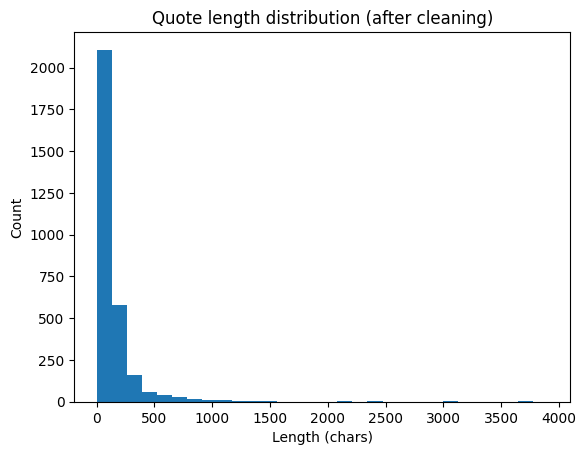

In [67]:
import matplotlib.pyplot as plt

lengths = df['quote'].str.len()
plt.hist(lengths, bins=30)
plt.title("Quote length distribution (after cleaning)")
plt.xlabel("Length (chars)")
plt.ylabel("Count")
plt.show()

In [68]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
vocab_size = 10000
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(quotes)



In [69]:
word_index = tokenizer.word_index
print(f"word_index: {len(word_index)}")
list(word_index.items())[:10]

word_index: 8724


[('<OOV>', 1),
 ('the', 2),
 ('you', 3),
 ('to', 4),
 ('and', 5),
 ('a', 6),
 ('i', 7),
 ('is', 8),
 ('of', 9),
 ('that', 10)]

In [70]:


from tensorflow.keras.preprocessing.text import Tokenizer
sequences = tokenizer.texts_to_sequences(quotes)

In [71]:
quotes[0]

'the world as we have created it is a process of our thinking it cannot be changed without changing our thinking'

In [72]:
sequences[1]

[11, 8, 71, 864, 374, 10, 433, 22, 20, 465, 15, 297, 53, 55, 71, 2428]

In [73]:
for i in range(3):
    print(quotes[i])


the world as we have created it is a process of our thinking it cannot be changed without changing our thinking
it is our choices harry that show what we truly are far more than our abilities
there are only two ways to live your life one is as though nothing is a miracle the other is as though everything is a miracle


In [74]:
for i in range(3):
    print(sequences[i])

[2, 63, 30, 20, 17, 938, 11, 8, 6, 1144, 9, 71, 286, 11, 147, 13, 805, 106, 742, 71, 286]
[11, 8, 71, 864, 374, 10, 433, 22, 20, 465, 15, 297, 53, 55, 71, 2428]
[43, 15, 54, 202, 707, 4, 82, 16, 36, 38, 8, 30, 313, 96, 8, 6, 1032, 2, 104, 8, 30, 313, 129, 8, 6, 1032]


In [75]:
X = []
y = []

for seq in sequences:
    for i in range (1, len(seq)):
        input_seq = seq[:i]
        output_seq = seq[i]
        X.append(input_seq)
        y.append(output_seq)

In [76]:
print(X[:5])


[[2], [2, 63], [2, 63, 30], [2, 63, 30, 20], [2, 63, 30, 20, 17]]


In [77]:
print(y[:5])

[63, 30, 20, 17, 938]


In [78]:
len(X)

85212

In [79]:
len(y)

85212

In [80]:
max_len = max(len (x)  for x in X)
print(max_len)


745


In [81]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
X_padded = pad_sequences(X, maxlen=max_len, padding='pre')
print(X_padded[0])


[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 

In [82]:
X[0]

[2]

In [83]:

import numpy as np
y = np.array(y)

In [84]:
X_padded.shape

(85212, 745)

In [85]:
from tensorflow.keras.utils import to_categorical
y_hot_coded = to_categorical(y, num_classes=vocab_size)
print(y_hot_coded.shape)

(85212, 10000)


In [86]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,SimpleRNN, LSTM, Dense

In [87]:
embedding_dim = 50
rnn_units = 128

rnn_model = Sequential()
rnn_model.add(Embedding(vocab_size, embedding_dim, input_length=max_len))
rnn_model.add(SimpleRNN(rnn_units))
rnn_model.add(Dense(vocab_size, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [88]:
rnn_model.compile( optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])
rnn_model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [89]:
epochs = 10

batch_size = 128


In [90]:
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping


lstm_model = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_len),
    LSTM(rnn_units),
    Dropout(0.3),
    Dense(vocab_size, activation="softmax"),
])

lstm_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])


history_lstm = lstm_model.fit(
    X_padded,
    y_hot_coded,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.1,
  
)

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 37s 59ms/step - accuracy: 0.0383 - loss: 6.7036 - val_accuracy: 0.0425 - val_loss: 6.6168
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 34s 57ms/step - accuracy: 0.0534 - loss: 6.3673 - val_accuracy: 0.0597 - val_loss: 6.5307
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 41s 57ms/step - accuracy: 0.0728 - loss: 6.1302 - val_accuracy: 0.0791 - val_loss: 6.4198
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 35s 58ms/step - accuracy: 0.0904 - loss: 5.9239 - val_accuracy: 0.0921 - val_loss: 6.3682
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 34s 57ms/step - accuracy: 0.1029 - loss: 5.7546 - val_accuracy: 0.1004 - val_loss: 6.3480
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 34s 57ms/step - accuracy: 0.1123 - loss: 5.5968 - val_accuracy: 0.1057 - val_loss: 6.3449
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 34s 57ms/step - accuracy: 0.1194 - loss: 5.4561 - val_accuracy: 0.1082 - val_loss: 6.3610
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 34s 57ms/step - accuracy: 0.1252 - loss: 5.3288 - 

In [91]:
# history_rnn = rnn_model.fit(X_padded, y_hot_coded, epochs=epochs, batch_size=batch_size, validation_split=0.1)

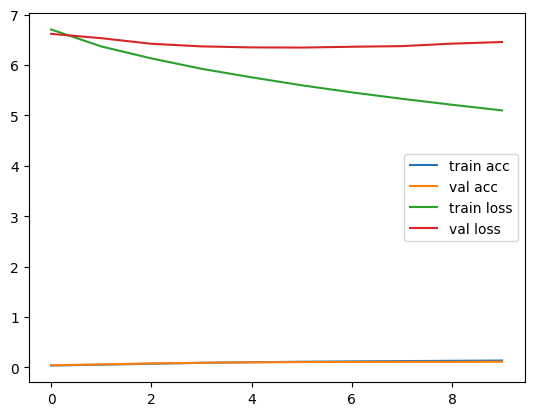

In [92]:
import matplotlib.pyplot as plt

plt.plot(history_lstm.history["accuracy"], label="train acc")
plt.plot(history_lstm.history["val_accuracy"], label="val acc")
plt.plot(history_lstm.history["loss"], label="train loss")
plt.plot(history_lstm.history["val_loss"], label="val loss")
plt.legend()
plt.show()

In [93]:
print("Training Accuracy:", history_lstm.history['accuracy'][-1])

Training Accuracy: 0.136249840259552


In [94]:
print("Validation Accuracy:", history_lstm.history['val_accuracy'][-1])

Validation Accuracy: 0.1131189838051796


In [95]:
print(y_hot_coded[:10])

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [96]:
index_to_word = {index: word for word, index in tokenizer.word_index.items()}

In [97]:
!ls /content

drive  max_len.pkl  sample_data  tokenizer.pkl


In [98]:
# import pickle

# # tokenizer save
# with open("tokenizer.pkl", "wb") as f:
#     pickle.dump(tokenizer, f)

# # max_len save
# with open("max_len.pkl", "wb") as f:
#     pickle.dump(max_len, f)

In [99]:
from google.colab import drive
drive.mount('/content/drive')
import pickle

# Model JSON save
model_json = lstm_model.to_json()
with open('/content/drive/MyDrive/nextword_model.json', 'w') as f:
    f.write(model_json)

# Weights save
lstm_model.save_weights('/content/drive/MyDrive/nextword_weights.weights.h5')

# Tokenizer save
with open('/content/drive/MyDrive/nextword_tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

# max_len save
with open('/content/drive/MyDrive/nextword_maxlen.pkl', 'wb') as f:
    pickle.dump(max_len, f)

print("✅ Done! 4 files saved!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Done! 4 files saved!


In [100]:
from google.colab import drive
drive.mount('/content/drive')
import pickle

# Model JSON save
model_json = model.to_json()
with open('/content/drive/MyDrive/nextword_model.json', 'w') as f:
    f.write(model_json)

# Weights save
model.save_weights('/content/drive/MyDrive/nextword_weights.weights.h5')

# Tokenizer save
with open('/content/drive/MyDrive/nextword_tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

# max_len save
with open('/content/drive/MyDrive/nextword_maxlen.pkl', 'wb') as f:
    pickle.dump(max_len, f)

print("✅ Done! 4 files saved!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


NameError: name 'model' is not defined

In [101]:
import os
os.listdir("/content/drive/MyDrive")

['Untitled document (2).gdoc',
 'Untitled document (1).gdoc',
 'Resume.gdoc',
 'Untitled document.gdoc',
 'Copy of Practise 1 (2).xlsx',
 'Copy of Practise 1 (3).gsheet',
 'Copy of Practise 1 (2).gsheet',
 'Copy of MOCK_Updated.gsheet',
 'Copy of Practise 1 (1).xlsx',
 'Copy of Practise 1 (1).gsheet',
 'Copy of Practise 1.xlsx',
 'Copy of Practise 1.gsheet',
 'Iris.csv',
 'Colab Notebooks',
 'deep learning course',
 'diabetes_prediction_dataset.csv',
 'rnn project.ipynb',
 'qoute_dataset.csv',
 'Fake.csv',
 'True.csv',
 'TSLA.csv',
 'Untitled',
 'lstm_project.ipynb',
 'lstm_model.h5',
 'Aman_Resume (1) (1).pdf',
 'Student_performance_data _.csv',
 'text_gen_model.h5',
 'seq_len.pkl',
 'fake_news_model.h5',
 'fake_news_tokenizer.pkl',
 'max_len.pkl',
 'fake_news_model_new.keras',
 'tokenizer.pkl',
 'fake_news_weights.weights.h5',
 'fake_news_model.json',
 'nextword_model.json',
 'nextword_weights.weights.h5',
 'nextword_tokenizer.pkl',
 'nextword_maxlen.pkl']

In [ ]:
# Ye cell run karo
%whos

Variable            Type              Data/Info
-----------------------------------------------
Dense               type              <class 'keras.src.layers.core.dense.Dense'>
Dropout             type              <class 'keras.src.layers.<...>ization.dropout.Dropout'>
EarlyStopping       type              <class 'keras.src.callbac<...>_stopping.EarlyStopping'>
Embedding           type              <class 'keras.src.layers.<...>ore.embedding.Embedding'>
LSTM                type              <class 'keras.src.layers.rnn.lstm.LSTM'>
Sequential          type              <class 'keras.src.models.sequential.Sequential'>
SimpleRNN           type              <class 'keras.src.layers.<...>nn.simple_rnn.SimpleRNN'>
Tokenizer           type              <class 'keras.src.legacy.<...>ocessing.text.Tokenizer'>
X                   list              n=85212
X_padded            ndarray           85212x745: 63482940 elems, type `int32`, 253931760 bytes (242.16819763183594 Mb)
batch_size          i